### 학습목표
- 네이버 블로그 데이터 수집하기
- 네이버 카페 데이터를 가져왔던 경험을 통하여 동일한 프로세스로 블로그 글 수집하기

##### 진행 순서
1. "음식물 처리기 사용 후기" 검색 결과 블로그 링크(url) 분석하기
2. 키워드 검색결과, 날짜 변경이 가능한 링크(url) 생성하기
3. driver를 통하여 페이지 요청하기
4. 블로그 주소 수집하기 (href_list)
5. 블로그 접근하여 데이터 수집하기
6. 코드 통합 (한번의 실행으로 전체 코드 작동)

In [2]:
from selenium import webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from tqdm import tqdm
import time
import re
from urllib.parse import quote
 
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w)
  w = w.strip()
  return w

In [5]:
# 1. "음식물 처리기 사용 후기" 검색 결과 블로그 링크(url) 분석하기
'''
https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3Aall # 전체
https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3A1h # 1시간
https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3A1m # 1개월
https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3A6m # 6개월
https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EC%9D%8C%EC%8B%9D%EB%AC%BC%20%EC%B2%98%EB%A6%AC%EA%B8%B0%20%EC%82%AC%EC%9A%A9%20%ED%9B%84%EA%B8%B0&sm=tab_opt&nso=so%3Ar%2Cp%3A1y # 1년

https://search.naver.com/search.naver?ssc=tab.kin.kqna&query=%EC%A4%91%EA%B3%A0%EA%B0%80%EC%A0%84%20%EA%B5%AC%EB%A7%A4&sm=tab_opt&nso=so:r,p:1y,sa:all&answer=0
https://search.naver.com/search.naver?ssc=tab.kin.kqna&query=%EC%A4%91%EA%B3%A0%EA%B0%80%EC%A0%84%20%EA%B5%AC%EB%A7%A4&sm=tab_opt&nso=so:r,p:6m,sa:all&answer=0
'''
# keyword = quote('음식물 처리기 사용 후기')
keyword = quote('중고가전 구매')
keyword

'%EC%A4%91%EA%B3%A0%EA%B0%80%EC%A0%84%20%EA%B5%AC%EB%A7%A4'

In [4]:
# 2. 키워드 검색결과, 날짜 변경이 가능한 링크(url) 생성하기
option = '1y' # 'All', '1h', '1m', '6m', '1y'
# url = f'https://search.naver.com/search.naver?ssc=tab.blog.all&query={keyword}&sm=tab_opt&nso=so%3Ar%2Cp%3A{option}' # 블로그
url = f'https://search.naver.com/search.naver?ssc=tab.kin.kqna&query={keyword}&sm=tab_opt&nso=so:r,p:{option},sa:all&answer=0'

In [6]:
# 3. driver를 통하여 페이지 요청하기
driver = wb.Chrome()
driver.get(url)
time.sleep(1)

# 웹페이지의 높이 값을 활용한 스크롤 내리기!
# 현재 페이지의 총 높이 추출 (이전페이지 높이, old_height)
old_height = driver.execute_script('return document.documentElement.scrollHeight')

# 반복문을 통하여 스크롤 -> 새로운 페이지와 높이를 비교하여 끝까지 내리기
while True:
    body = driver.find_element(By.TAG_NAME, 'body')
    body.send_keys(Keys.END)
    time.sleep(1)
    
    new_height = driver.execute_script('return document.documentElement.scrollHeight')
    print("new_height: ", new_height)
    if new_height == old_height:
        print('Done')
        break
    else:
        old_height = new_height

new_height:  4656
new_height:  6623
new_height:  8638
new_height:  10630
new_height:  12645
new_height:  14660
new_height:  16675
new_height:  18690
new_height:  20706
new_height:  22078
new_height:  22078
Done


In [ ]:
# 4. 지식인 주소 수집하기 (href_list)
contents = driver.find_elements(By.CSS_SELECTOR, 'a.jyxwDwu8umzdhCQxX48l.aRCEf_Blmd0fdPwuvuSM')
href_list = [c.get_attribute('href') for c in contents]
title_list = [c.text for c in contents]

print(len(href_list))
print(href_list[0])

print(len(title_list))
print(title_list[0])

107
https://kin.naver.com/qna/detail.naver?d1id=5&dirId=50404&docId=480654235&enc=utf8&kinsrch_src=pc_tab_kin&qb=7KSR6rOg6rCA7KCEIOq1rOunpA%3D%3D
107
중고가전 구매


In [ ]:
# 5. 블로그 접근하여 데이터 수집하기
f = open('네이버지식인_크롤링_중고가전구매.txt', 'w', encoding='utf-8')
# for href in tqdm(href_list):
for href in tqdm(href_list[:5]):
    driver.get(href)
    
    # iframe
    # driver.switch_to.frame('mainFrame')
    
    # content_ = driver.find_element(By.CSS_SELECTOR, 'div.se-main-container')
    content_ = driver.find_element(By.CSS_SELECTOR, 'div.questionDetail')
    print(content_.text)
    
    f.write(content_.text)

f.close()
# driver.quit()

 20%|██        | 1/5 [00:01<00:05,  1.40s/it]

2/7일(금) 이사 예정입니다.
당일 오전 중(11시 전후) 배송 원합니다.
위치는 인천 계산역 인근 아파트입니다.
엘베 없고 낮은 계단의 5층입니다. (같이 옮겨야 합니다.)

구매할 물품은 중고 가전 - 냉장고(500L)와 세탁기(15KG)입니다.

배송 필수, 내&외부 깨끗하고 하자없고 컨디션 괜찮은 물품을 찾습니다.

구매 희망 가격은 40~50만원 입니다.

+ 배송비/인건비 추가금액도 생각하고 있습니다.


 40%|████      | 2/5 [00:02<00:04,  1.36s/it]

계절이 바뀌면서 가전제품 몇가지 중고가전판매하고 새로 사고싶은데요
중고가전판매 할수있는 매장 괜찮은곳 알려주세요.
서울에 관악구쪽으로 알려주세요.
중고가전판매도하고 중고가전구매도 할수있는곳으로 알려주시면 좋겠습니다.
판매한돈으로 중고구매하면 저렴하게 살수있을것 같아서욯
그럼 답변좀 부탁합니다.


 60%|██████    | 3/5 [00:03<00:02,  1.19s/it]

부산 중고 가전제품 견적 문의합니다

구매시기 2023년8월경
삼성 일반형 냉장고 50만원대
삼성 통돌이 세탁기 40만원대
삼성 창문형 에어컨 50만원대

제조년월 및 모델, 상태에 따라 견적 다른 점 압니다만
최고가 매입 바라지않아요 대략적으로라도 견적 알고싶습니다
검색하면 광고글뿐이라서요 ㅜㅜ


 80%|████████  | 4/5 [00:04<00:01,  1.07s/it]

안녕하세요
이사하면서 사용했던 가전들 판매하려고합니다
세탁기,에어컨,냉장고 판매하려고 하는데
중고가전 매입하는곳 보니까 14년이전 제품은 구매안하신다고하시더라구요
저희집 제품들보니 12년 제품들인데 이정도되는 제품 매입하시는곳은 없나요ㅠㅠ


100%|██████████| 5/5 [00:05<00:00,  1.11s/it]

이사를 했는데 중고로 살려고 합니다.
 사는곳은 7호선 중화역부근이고
그 근처 중고 가전 매장이나
 아니면 서울에서 유명한 중고 가전 매장좀 추천해 주세요
 혼자 살기 때문에 세탁기나 냉장고 모두
조그만한 걸로 살려고 합니다.
 업자 분들 광고도 환영합니다.


In [ ]:
# 6. 코드 통합 (한번의 실행으로 전체 코드 작동)

keyword = quote('중고가전 구매')
option = '1y' # 'All', '1h', '1m', '6m', '1y'
url = f'https://search.naver.com/search.naver?ssc=tab.kin.kqna&query={keyword}&sm=tab_opt&nso=so:r,p:{option},sa:all&answer=0'

# driver를 통하여 페이지 요청하기
driver = wb.Chrome()
driver.get(url)
time.sleep(1)

# 웹페이지의 높이 값을 활용한 스크롤 내리기!
# 현재 페이지의 총 높이 추출 (이전페이지 높이, old_height)
old_height = driver.execute_script('return document.documentElement.scrollHeight')

# 반복문을 통하여 스크롤 -> 새로운 페이지와 높이를 비교하여 끝까지 내리기
while True:
    body = driver.find_element(By.TAG_NAME, 'body')
    body.send_keys(Keys.END)
    time.sleep(1)
    
    new_height = driver.execute_script('return document.documentElement.scrollHeight')
    print("new_height: ", new_height)
    if new_height == old_height:
        print('Done')
        break
    else:
        old_height = new_height
    
# 블로그 주소 수집하기 (href_list)
# contents = driver.find_elements(By.CSS_SELECTOR, 'a.ialLiYPc7XEN3dJ4Tujv.pHHExKwXvRWn4fm5O0Hr')
contents = driver.find_elements(By.CSS_SELECTOR, 'a.jyxwDwu8umzdhCQxX48l.aRCEf_Blmd0fdPwuvuSM')

href_list = [c.get_attribute('href') for c in contents]
title_list = [c.text for c in contents]

print("게시글(url) 개수: ", len(href_list))
print("첫 게시글 url: ", href_list[0])


# 블로그 접근하여 데이터 수집하기
f = open('네이버지식인_크롤링_중고가전구매.txt', 'w', encoding='utf-8')
for href in tqdm(href_list):
    driver.get(href)
    
    # iframe
    # driver.switch_to.frame('mainFrame')
    
    # content_ = driver.find_element(By.CSS_SELECTOR, 'div.se-main-container')
    content_ = driver.find_element(By.CSS_SELECTOR, 'div.questionDetail')
    
    f.write(content_.text)

f.close()
driver.quit()

new_height:  4656
new_height:  6623
new_height:  8638
new_height:  10630
new_height:  12645
new_height:  14660
new_height:  16675
new_height:  18690
new_height:  20706
new_height:  22078
new_height:  22078
Done
게시글(url) 개수:  107
첫 게시글 url:  https://kin.naver.com/qna/detail.naver?d1id=5&dirId=50404&docId=480654235&enc=utf8&kinsrch_src=pc_tab_kin&qb=7KSR6rOg6rCA7KCEIOq1rOunpA%3D%3D


100%|██████████| 107/107 [01:23<00:00,  1.28it/s]


##### 7. 워드클라우드 시각화

In [7]:
from kiwipiepy import Kiwi # 형태소 분석기
from collections import Counter # 단어가 나온 횟수를 셈
from wordcloud import WordCloud # 워드클라우드 생성 도구
import matplotlib.pyplot as plt # 시각화 도구
from PIL import Image
import numpy as np

In [8]:
# f = open('./data/네이버 블로그 내용.txt', 'r', encoding='utf-8')
f = open('네이버지식인_크롤링_중고가전구매.txt', 'r', encoding='utf-8')
review = f.read()
f.close()
print(len(review))
#print(review)

17818


In [10]:
# 도구 객체생성
kiwi = Kiwi()

# 토큰화
token = kiwi.tokenize(review)
token

# form: 토큰화 결과
# tag: 품사 태그
# nnp: 고유명사; nng: 일반명사

[Token(form='2/7', tag='W_SERIAL', start=0, len=3),
 Token(form='일', tag='NNB', start=3, len=1),
 Token(form='(', tag='SSO', start=4, len=1),
 Token(form='금', tag='NNG', start=5, len=1),
 Token(form=')', tag='SSC', start=6, len=1),
 Token(form='이사', tag='NNG', start=8, len=2),
 Token(form='예정', tag='NNG', start=11, len=2),
 Token(form='이', tag='VCP', start=13, len=1),
 Token(form='ᆸ니다', tag='EF', start=13, len=3),
 Token(form='.', tag='SF', start=16, len=1),
 Token(form='당일', tag='NNG', start=18, len=2),
 Token(form='오전', tag='NNG', start=21, len=2),
 Token(form='중', tag='NNB', start=24, len=1),
 Token(form='(', tag='SSO', start=25, len=1),
 Token(form='11', tag='SN', start=26, len=2),
 Token(form='시', tag='NNB', start=28, len=1),
 Token(form='전후', tag='NNG', start=30, len=2),
 Token(form=')', tag='SSC', start=32, len=1),
 Token(form='배송', tag='NNG', start=34, len=2),
 Token(form='원', tag='NNG', start=37, len=1),
 Token(form='하', tag='XSV', start=38, len=1),
 Token(form='ᆸ니다', tag='EF'

In [11]:
# 일반명사만 추출 (NNG)
# 리스트명 = [실행문 반복문 조건]
# nng_token = [t.form for t in token if t.tag=='NNG']
nngp_token = [t.form for t in token if t.tag=='NNG' or t.tag=='NNP']

print(len(nngp_token))
#print(nngp_token)

2491


In [12]:
# 2글자 이상의 단어만 추출
nngp_token2 = [t for t in nngp_token if len(t)>=2]
nngp_token2

['이사',
 '예정',
 '당일',
 '오전',
 '전후',
 '배송',
 '위치',
 '인천',
 '계산역',
 '인근',
 '아파트',
 '엘베',
 '계단',
 '구매',
 '물품',
 '중고',
 '가전',
 '냉장고',
 '세탁기',
 '배송',
 '필수',
 '외부',
 '하자',
 '컨디션',
 '물품',
 '구매',
 '희망',
 '가격',
 '배송비',
 '인건비',
 '추가',
 '금액',
 '생각',
 '계절',
 '가전제품',
 '중고',
 '가전',
 '판매',
 '중고',
 '가전',
 '판매',
 '매장',
 '서울',
 '관악구',
 '중고',
 '가전',
 '판매',
 '중고',
 '가전',
 '구매',
 '판매',
 '중고',
 '구매',
 '답변',
 '부탁',
 '부산',
 '중고',
 '가전제품',
 '견적',
 '문의',
 '구매',
 '시기',
 '삼성',
 '일반',
 '냉장고',
 '삼성',
 '통돌이',
 '세탁기',
 '삼성',
 '창문',
 '에어컨',
 '제조',
 '모델',
 '상태',
 '견적',
 '최고',
 '매입',
 '대략',
 '견적',
 '검색',
 '광고',
 '안녕하세요',
 '이사',
 '사용',
 '가전',
 '판매',
 '세탁기',
 '에어컨',
 '냉장고',
 '판매',
 '중고',
 '가전',
 '매입',
 '이전',
 '제품',
 '구매',
 '제품',
 '제품',
 '정도',
 '제품',
 '매입',
 '이사',
 '중고',
 '중화역',
 '부근',
 '근처',
 '중고',
 '가전',
 '매장',
 '서울',
 '유명',
 '중고',
 '가전',
 '매장',
 '추천',
 '세탁기',
 '냉장고',
 '업자',
 '광고',
 '환영',
 '계약직',
 '촉탁',
 '중고',
 '가전',
 '구매',
 '계약',
 '기간',
 '본가',
 '예정',
 '가전',
 '이사',
 '가전',
 '제품',
 '부산',
 '사람',
 '서울',
 '지리',
 '이사',
 '날짜',
 

In [13]:
# 명사의 개수를 세서 많이 나오는 단어를 활용하여 워드클라우드 생성하기
counter = Counter(nngp_token2)
counter

Counter({'중고': 99,
         '구매': 79,
         '가전': 67,
         '냉장고': 57,
         '세탁기': 42,
         '에어컨': 41,
         '이사': 35,
         '제품': 35,
         '사용': 28,
         '정도': 28,
         '판매': 24,
         '가격': 22,
         '매장': 20,
         '가전제품': 19,
         '부탁': 18,
         '가능': 18,
         '설치': 17,
         '업체': 17,
         '매입': 16,
         '가구': 16,
         '고장': 15,
         '구입': 14,
         '수리': 13,
         '시간': 13,
         '안녕': 12,
         '상태': 11,
         '추천': 11,
         '기간': 11,
         '지역': 11,
         '얼마': 11,
         '문제': 11,
         '답변': 10,
         '방문': 10,
         '필요': 10,
         '물건': 10,
         '거래': 10,
         '수거': 10,
         '예정': 9,
         '배송': 9,
         '문의': 9,
         '인터넷': 9,
         '비용': 9,
         '환불': 9,
         '벽걸이': 9,
         '상품': 9,
         '금액': 8,
         '삼성': 8,
         '사람': 8,
         '경우': 8,
         '잔금': 8,
         '티비': 8,
         '작동': 8,
         '연락': 8,
  

In [14]:
# 상위 N개 단어만 추출
top_N = counter.most_common(50)
top_N

[('중고', 99),
 ('구매', 79),
 ('가전', 67),
 ('냉장고', 57),
 ('세탁기', 42),
 ('에어컨', 41),
 ('이사', 35),
 ('제품', 35),
 ('사용', 28),
 ('정도', 28),
 ('판매', 24),
 ('가격', 22),
 ('매장', 20),
 ('가전제품', 19),
 ('부탁', 18),
 ('가능', 18),
 ('설치', 17),
 ('업체', 17),
 ('매입', 16),
 ('가구', 16),
 ('고장', 15),
 ('구입', 14),
 ('수리', 13),
 ('시간', 13),
 ('안녕', 12),
 ('상태', 11),
 ('추천', 11),
 ('기간', 11),
 ('지역', 11),
 ('얼마', 11),
 ('문제', 11),
 ('답변', 10),
 ('방문', 10),
 ('필요', 10),
 ('물건', 10),
 ('거래', 10),
 ('수거', 10),
 ('예정', 9),
 ('배송', 9),
 ('문의', 9),
 ('인터넷', 9),
 ('비용', 9),
 ('환불', 9),
 ('벽걸이', 9),
 ('상품', 9),
 ('금액', 8),
 ('삼성', 8),
 ('사람', 8),
 ('경우', 8),
 ('잔금', 8)]

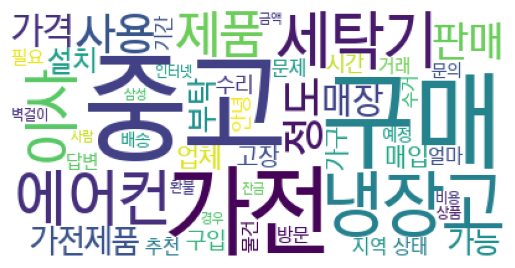

In [15]:
# WordCloud(): 스타일(배경,글꼴), 최대단어수, 마스크이미지 등 옵션을 설정
# generate_from_frequencies(): 미리 정의된 단어의 빈도수를 이용해서 워드클라우드 이미지를 생성

wc = WordCloud(
    font_path='C:/Windows/Fonts/LG PC.ttf', # malgunbd.ttf
    background_color='white'
    # mask=mask
        
).generate_from_frequencies(dict(top_N))

plt.imshow(wc)
plt.axis('off')
plt.show()